# Training simulation assignment - student

Run on yolo_mps_v11

## Return instructions

For return write your comments and observations into this ipynb
using moarkdown cells.

Return the notebook so that the outputs of the code cells are not cleared 
(=teacher should see the execution output of the cells).

## Baseline model

In [21]:
# TODO: imports here
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# If you want consistent results on your Mac:
#tf.config.set_visible_devices([], "GPU")


In [22]:
# TODO: write a function that reads the mnist dataset (hadwritten digits)
# splits the dataset into three: train, validation and test sets.
# The number of train samples is the input parameter to this function,
# validation and test sets are always 10000 samples. Suffle the training set once.
# return the train, validation and test x and y values.
# -----------------------
# 1) load_data
# -----------------------
def load_data(N_TRAIN=50000,N_VAL=10000):
  (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

  x_train = x_train.reshape(-1,784).astype("float32") / 255.0
  x_test  = x_test.reshape(-1,784).astype("float32") / 255.0

  x_val, y_val = x_train[-N_VAL:], y_train[-N_VAL:]  
  x_tr, y_tr = x_train[:-N_VAL], y_train[:-N_VAL]  
  x_tr, y_tr = x_tr[: N_TRAIN], y_tr[: N_TRAIN] # should check the size

  idx = np.random.permutation(len(x_tr))
  x_tr, y_tr = x_tr[idx], y_tr[idx]

  print(f"Train: {x_tr.shape} val: {x_val.shape} test: {x_test.shape} ")
  return x_tr, y_tr, x_val, y_val, x_test, y_test

In [23]:
# TODO: Write a function that makes a baseline ANN model with
# Dense(256)+Dense(128)+Dense(10) layers. Use Adam optimizer with a suitable
# learning rate and SparseCategoricalCrossentropy as loss function.
# Compile the model and measure the accuracy as metrics.
# Return the compiled model.
# -----------------------
# 2) Baseline ANN
# -----------------------
def make_base_model(lr=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation="relu", input_shape=(784, )),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10) # no softmax -> produces logists as outputs
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=opt, loss=loss_fn, metrics=["accuracy"])
    model.summary()
    return model


In [24]:
# TODO: Write a function that trains baseline ANN model
# using following function signature (shown below).
# Return the traing and validation data.
# -----------------------
# 3) Train
# -----------------------
def train_base_model(model, EPOCHS, x_tr, y_tr, x_val, y_val,batch_size=128,verbose=1):
  # :
  history = model.fit(x_tr, y_tr, epochs=EPOCHS, batch_size=batch_size, validation_data=(x_val, y_val), verbose=verbose)
  return history

In [25]:
# TODO: Write a plot_loss_acc() function that plots 
# the following training curves:
# training and validation accuracy in one plot and
# training and validation loss in another plot
# -----------------------
# 4) Curves: train vs val
# -----------------------
def plot_loss_acc(history):

  # VISUALIZE accuracies and losses
  plt.figure()
  plt.plot(history.history["loss"], label="train loss")
  plt.plot(history.history["val_loss"], label="val_loss")
  plt.legend()
  plt.grid()
  plt.show()

  # VISUALIZE accuracies and losses
  plt.figure()
  plt.plot(history.history["accuracy"], label="training_accuracy")
  plt.plot(history.history["val_accuracy"], label="val_accuracy")
  plt.legend()
  plt.grid()
  plt.show()


Train: (55000, 784) val: (5000, 784) test: (10000, 784) 


c:\Users\Parrot\anaconda3\envs\ANACONDA_NEURAL_NETWORKS_ENV\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9161 - loss: 0.2878 - val_accuracy: 0.9676 - val_loss: 0.1137
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9662 - loss: 0.1102 - val_accuracy: 0.9754 - val_loss: 0.0816
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9781 - loss: 0.0698 - val_accuracy: 0.9770 - val_loss: 0.0750
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9849 - loss: 0.0490 - val_accuracy: 0.9780 - val_loss: 0.0773
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9889 - loss: 0.0358 - val_accuracy: 0.9772 - val_loss: 0.0879
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9906 - loss: 0.0299 - val_accuracy: 0.9784 - val_loss: 0.0756
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9927 - loss: 0.0219 - val_accuracy: 0.9756 - val_loss: 0.1007
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9943 - loss: 0.0172 - val_accuracy: 0.

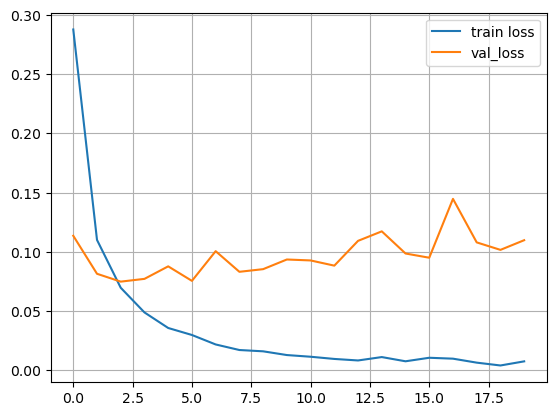

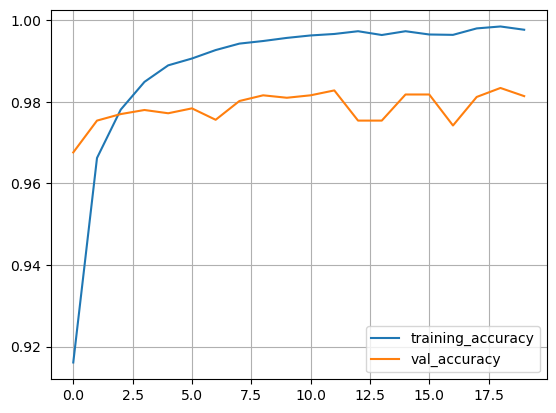

313/313 - 0s - 1ms/step - accuracy: 0.9814 - loss: 0.0979
Test loss: 0.0979 | Test acc: 0.9814


In [26]:
# TODO: Write code that 
# calls the load_data() function to define the train, validation and test sets.
# Training dataset size is 50 000 samples. 
# Make the baseline ANN model and compile it.
# Train the base model and track the progress. Parameters fo this are:
# - EPOCHS = 20
# - batch_size = 128
# Plot the training and validation accuracy and loss using the plot_loss_acc function.
# Finally evaluate the model accuracy and loss and print it to the console.
# Make conclusions about the training plots and accuracy of the test samples.
# :

N_TRAIN = 60000 - 5000
N_VAL = 5000
learning_rate = 1e-3
EPOCHS = 20
batch_size = 128
verbose_lvl = 1

x_tr, y_tr, x_val, y_val, x_test, y_test = load_data(N_TRAIN, N_VAL)

base_model = make_base_model(learning_rate)

base_history = train_base_model(base_model, EPOCHS, x_tr, y_tr, x_val, y_val, batch_size, verbose_lvl)

plot_loss_acc(base_history)

# -----------------------
# 5) Test evaluation
# -----------------------
# :
test_loss, test_acc = base_model.evaluate(x_test, y_test, verbose=2)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

# Conclusions:

## Case 1 High Capacity ANN

Decreasing the training dataset size to 1000/2000

In [27]:
# TODO: Write a function that makes a high capacity ANN model with
# Dense(1024)+Dense(1024)+Dense(512)+Dense(10) layers. Use Adam optimizer with a suitable
# learning rate and SparseCategoricalCrossentropy as loss function.
# Compile the model and measure the accuracy as metrics.
# Return the compiled hc model.
# -----------------------
# High-capacity ANN (no regularization)
# -----------------------
def make_hc_model(lr=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1024, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(10)
    ])

    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=opt, loss=loss_fn, metrics=["accuracy"])
    model.summary()
    
    return model


In [28]:
# TODO: Write a function that trains hc ANN model
# using following function signature (shown below).  
# Return the traing and validation data.
# -----------------------
# Train 
# -----------------------

#def train_hc_model(model, EPOCHS, x_tr, y_tr, x_val, y_val, batch_size, verbose):
    #history = model.fit(x_tr, y_tr, epochs=EPOCHS, batch_size=batch_size, validation_data=(x_val, y_val), verbose=verbose)

def train_hc_model(model, EPOCHS, x_tr, y_tr, x_val, y_val, batch_size, early_stopping=False, patience=3, verbose=1):
    if not early_stopping:
        history = model.fit(
        x_tr, 
        y_tr, 
        epochs=EPOCHS, 
        batch_size=batch_size, 
        validation_data=(x_val, y_val), 
        verbose=verbose
        )
    else:
       # monitor defines what is the value that decided if training stops or not
       cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
       history = model.fit(x_tr, y_tr, epochs=EPOCHS, batch_size=batch_size, validation_data=(x_val, y_val), callbacks=[cb], verbose=verbose)
        
    return history




Train: (1000, 784) val: (500, 784) test: (10000, 784) 


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,383,370 (9.09 MB)

 Trainable params: 2,383,370 (9.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6000 - loss: 1.3280 - val_accuracy: 0.8560 - val_loss: 0.4330
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8590 - loss: 0.4768 - val_accuracy: 0.9060 - val_loss: 0.3719
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9200 - loss: 0.2485 - val_accuracy: 0.8900 - val_loss: 0.3782
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9610 - loss: 0.1334 - val_accuracy: 0.9340 - val_loss: 0.2940
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9870 - loss: 0.0584 - val_accuracy: 0.9400 - val_loss: 0.3043
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9950 - loss: 0.0273 - val_accuracy: 0.9380 - val_loss: 0.3122
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.9420 - val_loss: 0.3331


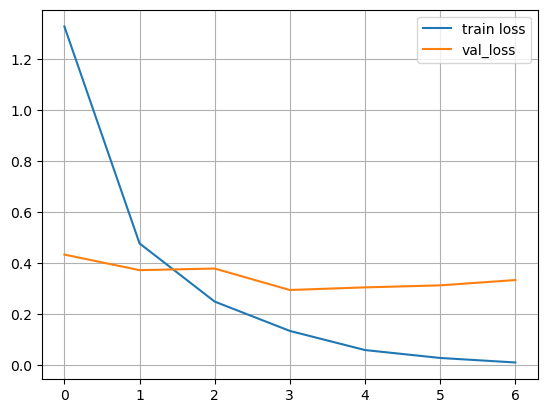

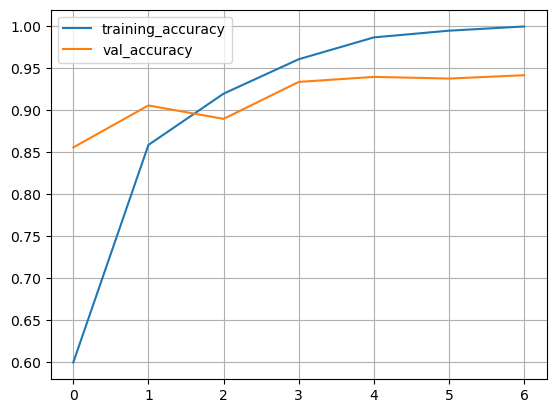

313/313 - 1s - 2ms/step - accuracy: 0.8813 - loss: 0.3958
Test loss: 0.3958 | Test acc: 0.8813


In [29]:
# TODO: Write code that 
# calls the load_data() function to define the train, validation and test sets.
# Training dataset size is now 1000 samples. 
# Make the hc ANN model and compile it.
# Train the hc model and track the progress. Parameters fo this are:
# - EPOCHS = 20
# - batch_size = 128
# Plot the training and validation accuracy and loss using the plot_loss_acc function.
# Finally evaluate the model accuracy and loss and print it to the console.
# Make conclusions about the training plots and accuracy of the test samples.

N_TRAIN = 1000
N_VAL = 500
learning_rate = 1e-3
EPOCHS = 50
batch_size = 128
verbose_lvl = 1

early_stopping = True
# patience 3 means, if not during 3 epochs improvements, stop training
patience = 3

x_tr, y_tr, x_val, y_val, x_test, y_test = load_data(N_TRAIN, N_VAL)

hc_model = make_hc_model(learning_rate)

#hc_history = train_hc_model(hc_model, EPOCHS, x_tr, y_tr, x_val, y_val, batch_size, verbose_lvl)
hc_history = train_hc_model(
    model=hc_model, 
    EPOCHS=EPOCHS, 
    x_tr=x_tr, 
    y_tr=y_tr, 
    x_val=x_val, 
    y_val=y_val, 
    batch_size=batch_size, 
    patience=patience,
    early_stopping=early_stopping,
    verbose=verbose_lvl)

plot_loss_acc(hc_history)

# -----------------------
# 5) Test evaluation
# -----------------------
# :
hc_test_loss, hc_test_acc = hc_model.evaluate(x_test, y_test, verbose=2)
print(f"Test loss: {hc_test_loss:.4f} | Test acc: {hc_test_acc:.4f}")

## Case 2 High Capacity ANN using dropout and regularization

Increasing the data set size to 8000 and add dropout as well as regularization


In [30]:
# TODO: Write a function that makes a high capacity ANN model using dropout and regularization with
# Dense(1024)+Dropout(0.4)+Dense(1024)+Dropout(0.4)+Dense(512)+Dropout(0.3)+Dense(10) layers. 
# Use Adam optimizer with a suitable learning rate and SparseCategoricalCrossentropy as loss function.
# Compile the model and measure the accuracy as metrics.
# Return the compiled hc model.
# -----------------------
# High-capacity ANN (regularization + dropout)
# -----------------------

def make_hc_with_dropout_model(lr, dropout, dropout_last, l2):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1024, activation='relu', input_shape=(784,), kernel_regularizer=tf.keras.regularizers.l2(l2)),
        tf.keras.layers.Dropout(dropout),

        tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)),
        tf.keras.layers.Dropout(dropout_last),
        tf.keras.layers.Dense(10)
    ])

    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=opt, loss=loss_fn, metrics=["accuracy"])
    model.summary()
    
    return model


In [31]:
# TODO: Write a function that trains high capacity ANN model using dropout and regularization
# using following function signature (shown below). Return the traing and validation data.
# -----------------------
# Train 
# -----------------------
def train_hc_with_dropout_model(model, EPOCHS, x_tr, y_tr, x_val, y_val, batch_size, early_stopping=False, patience=3, verbose=1):
    if not early_stopping:
        history = model.fit(
        x_tr, 
        y_tr, 
        epochs=EPOCHS, 
        batch_size=batch_size, 
        validation_data=(x_val, y_val), 
        verbose=verbose
        )
    else:
       # monitor defines what is the value that decided if training stops or not
       cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
       history = model.fit(x_tr, y_tr, epochs=EPOCHS, batch_size=batch_size, validation_data=(x_val, y_val), callbacks=[cb], verbose=verbose)
        
    return history


Train: (8000, 784) val: (1000, 784) test: (10000, 784) 


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,383,370 (9.09 MB)

 Trainable params: 2,383,370 (9.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7860 - loss: 2.6387 - val_accuracy: 0.9440 - val_loss: 1.7475
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9211 - loss: 1.5925 - val_accuracy: 0.9660 - val_loss: 1.3085
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9438 - loss: 1.2003 - val_accuracy: 0.9550 - val_loss: 1.0703
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9557 - loss: 0.9476 - val_accuracy: 0.9640 - val_loss: 0.8389
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9594 - loss: 0.7739 - val_accuracy: 0.9550 - val_loss: 0.7386
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9675 - loss: 0.6417 - val_accuracy: 0.9590 - val_loss: 0.6545
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9653 - loss: 0.5630 - val_accuracy: 0.9640 - val_loss: 0.5637
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9664 - loss: 0.5056 - val_accuracy: 0.9700 - v

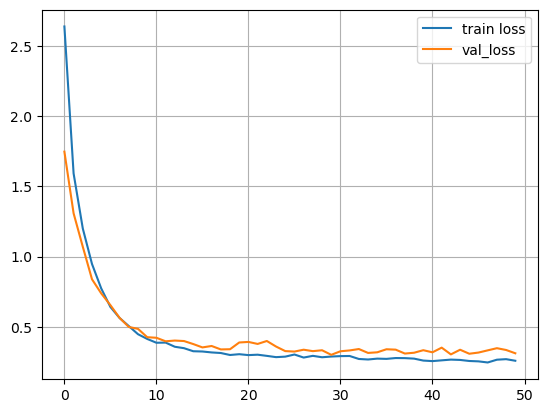

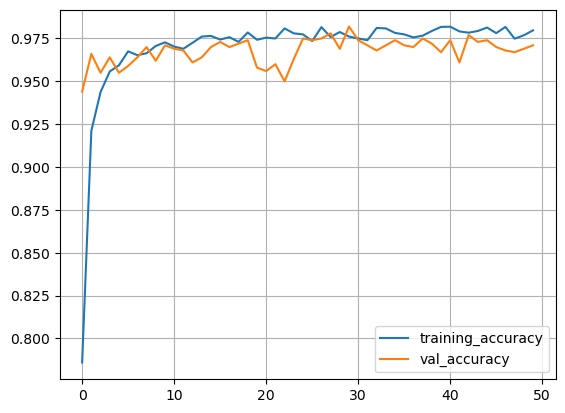

313/313 - 1s - 3ms/step - accuracy: 0.8813 - loss: 0.3958
Test loss: 0.3958 | Test acc: 0.8813


In [32]:
# TODO: Write code that
# calls the load_data() function to define the train, validation and test sets.
# Training dataset size is now 8000 samples. 
# Make the hc ANN using dropout and regularization model and compile it.
# Train the hc ANN using dropout and regularization model and 
# track the progress. Parameters fo this are:
# - EPOCHS = 20
# - batch_size = 128
# - learning rate 1e-3
# - dropout 0.4 (last 0.3)
# - l2 regularization 1e-4
# Plot the training and validation accuracy and loss using the plot_loss_acc function.
# Finally evaluate the model accuracy and loss and print it to the console.
# Make conclusions about the training plots and accuracy of the test samples.

N_TRAIN = 8000
N_VAL = 1000
learning_rate = 1e-3
EPOCHS = 50
batch_size = 128
verbose_lvl = 1

early_stopping = False
patience = 3

dropout = 0.4
dropout_last = 0.3
l2 = 1e-3


x_tr, y_tr, x_val, y_val, x_test, y_test = load_data(N_TRAIN, N_VAL)
hc_model_with_dropout = make_hc_with_dropout_model(learning_rate, dropout, dropout_last, l2)

#hc_history = train_hc_model(hc_model, EPOCHS, x_tr, y_tr, x_val, y_val, batch_size, verbose_lvl)
hc_with_dropout_history = train_hc_with_dropout_model(
    model=hc_model_with_dropout, 
    EPOCHS=EPOCHS, 
    x_tr=x_tr, 
    y_tr=y_tr, 
    x_val=x_val, 
    y_val=y_val, 
    batch_size=batch_size, 
    patience=patience,
    early_stopping=early_stopping,
    verbose=verbose_lvl)

plot_loss_acc(hc_with_dropout_history)

# -----------------------
# 5) Test evaluation
# -----------------------
# :
hc_with_dropout_test_loss, hc_with_dropout_test_acc = hc_model.evaluate(x_test, y_test, verbose=2)
print(f"Test loss: {hc_with_dropout_test_loss:.4f} | Test acc: {hc_with_dropout_test_acc:.4f}")

## Case 3 High Capacity ANN using dropout and regularization

Decreasing the training data set size back to 1000


Train: (2000, 784) val: (500, 784) test: (10000, 784) 


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,383,370 (9.09 MB)

 Trainable params: 2,383,370 (9.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5615 - loss: 3.7363 - val_accuracy: 0.9000 - val_loss: 2.5127
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8325 - loss: 2.5610 - val_accuracy: 0.9220 - val_loss: 2.1717
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8990 - loss: 2.1329 - val_accuracy: 0.9240 - val_loss: 2.0009
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9120 - loss: 1.8928 - val_accuracy: 0.9440 - val_loss: 1.8028
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9435 - loss: 1.6723 - val_accuracy: 0.9540 - val_loss: 1.6752
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9500 - loss: 1.5267 - val_accuracy: 0.9540 - val_loss: 1.5710
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9610 - loss: 1.3888 - val_accuracy: 0.9540 - val_loss: 1.4811
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9720 - loss: 1.2747 - val_accuracy: 0.9540 - v

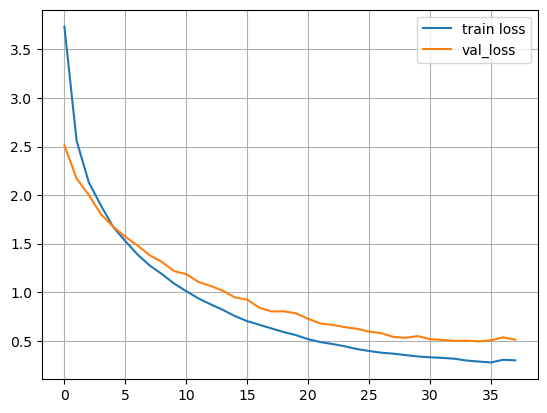

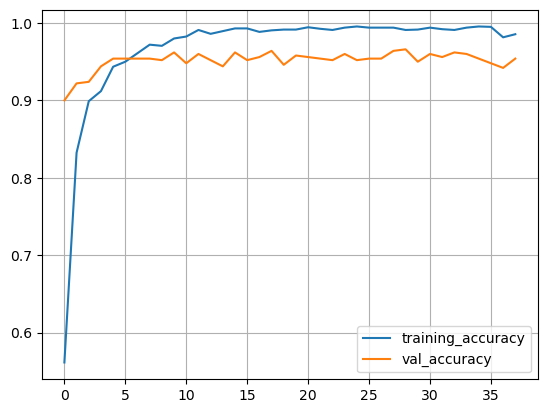

313/313 - 1s - 2ms/step - accuracy: 0.8813 - loss: 0.3958
Test loss: 0.3958 | Test acc: 0.8813
Test loss: 0.3958 | Test acc: 0.8813


In [36]:
# TODO: Write code that
# calls the load_data() function to define the train, validation and test sets.
# Training dataset size is now 2000 samples. 
# Make the hc ANN using dropout and regularization model and compile it.
# Train the hc ANN using dropout and regularization model and 
# track the progress. Parameters for this are:
# - EPOCHS = 20
# - batch_size = 128
# - learning rate 1e-3
# - dropout 0.5 (last 0.4)
# - l2 regularization 1e-4
# Plot the training and validation accuracy and loss using the plot_loss_acc function.
# Finally evaluate the model accuracy and loss and print it to the console.
# Make conclusions about the training plots and accuracy of the test samples.

N_TRAIN = 2000
N_VAL = 500
learning_rate = 1e-3
EPOCHS = 50
batch_size = 128
verbose_lvl = 1

early_stopping = True
patience = 3

dropout = 0.4
dropout_last = 0.3
l2 = 1e-3


x_tr, y_tr, x_val, y_val, x_test, y_test = load_data(N_TRAIN, N_VAL)
hc_model_with_dropout_b = make_hc_with_dropout_model(learning_rate, dropout, dropout_last, l2)

#hc_history = train_hc_model(hc_model, EPOCHS, x_tr, y_tr, x_val, y_val, batch_size, verbose_lvl)
hc_with_dropout_history = train_hc_with_dropout_model(
    model=hc_model_with_dropout_b, 
    EPOCHS=EPOCHS, 
    x_tr=x_tr, 
    y_tr=y_tr, 
    x_val=x_val, 
    y_val=y_val, 
    batch_size=batch_size, 
    patience=patience,
    early_stopping=early_stopping,
    verbose=verbose_lvl)

plot_loss_acc(hc_with_dropout_history)

# -----------------------
# 5) Test evaluation
# -----------------------
# :
hc_with_dropout_test_loss_b, hc_with_dropout_test_acc_b = hc_model.evaluate(x_test, y_test, verbose=2)
print(f"Test loss: {hc_with_dropout_test_loss_b:.4f} | Test acc: {hc_with_dropout_test_acc_b:.4f}")

# -----------------------
# Test evaluation
# -----------------------
# :
print(f"Test loss: {hc_with_dropout_test_loss_b:.4f} | Test acc: {hc_with_dropout_test_acc_b:.4f}")
